## Build a Basic Chatbot(with LangGraph GraphAPI)



In [7]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages


In [8]:
add_messages

<function langgraph.graph.message._add_messages_wrapper.<locals>._add_messages(left: 'Messages | None' = None, right: 'Messages | None' = None, **kwargs: 'Any') -> 'Messages | Callable[[Messages, Messages], Messages]'>

In [9]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function is reducer
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    messages:Annotated[list,add_messages]
    
graph_builder=StateGraph(State)

In [10]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [11]:
from langchain.chat_models import init_chat_model

os.environ['GROQ_API_KEY']=os.getenv('GROQ_API_KEY')

llm=init_chat_model("groq:openai/gpt-oss-120b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CF40768050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CF40768D70>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [12]:
def chatbot(state:State):
    return {'messages': [llm.invoke(state['messages'])]}

In [13]:
graph_builder=StateGraph(State)

graph_builder.add_node('llmchatbot', chatbot)

graph_builder.add_edge(START, 'llmchatbot')
graph_builder.add_edge('llmchatbot', END)

graph=graph_builder.compile()

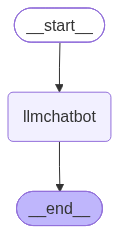

In [14]:
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass

In [15]:
responce=graph.invoke({"messages":"Hi, tell me about Langgraph"})

In [16]:
responce['messages'][-1].content

'Sure!\u202fLangGraph is an open‑source Python library that makes it easy to build **graph‑structured** workflows for large‑language‑model (LLM) applications. Think of it as a higher‑level orchestration layer on top of LangChain (or any other LLM‑toolkit) that lets you define **nodes** (individual steps) and **edges** (the flow of data and control) in a clear, declarative way.\n\nBelow is a quick rundown of what LangGraph offers, why you might want to use it, and a simple example to get you started.\n\n---\n\n## 1. Core Concepts\n\n| Concept | What it means | Typical implementation |\n|---------|---------------|------------------------|\n| **Node** | A single unit of work – e.g., calling an LLM, a retrieval step, a transformation, a tool call, etc. | Usually a `Runnable` (from LangChain) or any callable that takes a dict and returns a dict. |\n| **Edge** | The directed connection between nodes that determines how data flows. Edges can be unconditional or conditional (branching). | Defi

In [17]:
for event in graph.stream({'messages': 'Hi can you give me your model details such as token limit, model name, max tokens ets as a key value pairs'}):
    print(event)
    for values in event.values():
        print(values['messages'][-1].content)

{'llmchatbot': {'messages': [AIMessage(content='**Model Details (Key‑Value Pairs)**  \n\n- **model_name**: GPT‑4 (ChatGPT)  \n- **architecture**: Transformer‑based large language model  \n- **training_data_cutoff**: September\u202f2021 (knowledge updated to June\u202f2024)  \n- **max_context_length**: 8\u202f192 tokens (prompt\u202f+\u202fcompletion) – higher‑capacity variants (e.g., GPT‑4‑Turbo) can handle up to 128\u202fk tokens  \n- **max_output_tokens**: Typically up to 2\u202f048 tokens per response (subject to overall context limit)  \n- **tokenizer**: Byte‑Pair Encoding (BPE) with a vocabulary of ~50\u202fk tokens  \n- **temperature_range**: 0.0\u202f–\u202f2.0 (default 1.0)  \n- **top_p_range**: 0.0\u202f–\u202f1.0 (default 1.0)  \n- **stop_sequences**: Customizable per request  \n- **availability**: Accessible via OpenAI API and ChatGPT UI (ChatGPT Plus/Enterprise)  \n\n*Note: Exact limits may vary slightly depending on the specific deployment (e.g., GPT‑4‑Turbo, custom‑tuned 

In [18]:
from langchain_tavily import TavilySearch

tool=TavilySearch(max_results=2)
tool.invoke('What is langgraph?')

{'query': 'What is langgraph?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.geeksforgeeks.org/machine-learning/what-is-langgraph',
   'title': 'What is LangGraph - GeeksforGeeks',
   'content': 'LangGraph is an open-source framework from LangChain designed to build and manage AI agent workflows using graph-based structures. It allows developers to define workflows as nodes and edges, making complex agent interactions more structured, scalable and easier to control. [...] langgraph: Framework for building graph-based AI workflows.\n langchain: Popular toolkit for LLM-powered AI applications.\n google-generativeai: Google’s API for Generative AI (Gemini models).\n\n Python  ````\n! pip install langgraph langchain google - generativeai\n```` \n\n### Step 2: Setup Gemini API',
   'score': 0.95488787,
   'raw_content': None,
   'id': 'c7bbb2-00'},
  {'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph? | IBM

In [19]:
## Custom function
def multiply(a:int,b:int)->int:
    """Multiply a and b

    Args:
        a (int): first int
        b (int): second int

    Returns:
        int: output int
    """
    return a*b

In [20]:
tools=[tool,multiply]

In [21]:
llm_with_tool=llm.bind_tools(tools)

In [22]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 120B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001CF40768050>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001CF40768D70>, model_name='openai/gpt-oss-120b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, an

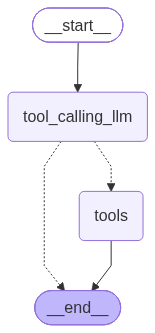

In [23]:
## StateGraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [30]:
response=graph.invoke({'messages': "Get me latest new on Laya Models"})

In [31]:
response['messages']

[HumanMessage(content='Get me latest new on Laya Models', additional_kwargs={}, response_metadata={}, id='396122d9-d5f0-4ce7-a041-13e2abfd8c02'),
 AIMessage(content='', additional_kwargs={'reasoning_content': 'User wants latest news on "Laya Models". Likely refers to Laya, a 3D/2D game engine? Or "LLaMA models"? "Laya Models" might be a typo for "Llama Models"? Could be about "Laya" as a Chinese AI model? Let\'s search.', 'tool_calls': [{'id': 'fc_a51a75bf-90eb-4e15-9d7c-20d8985c8694', 'function': {'arguments': '{"query":"Laya Models news","search_depth":"advanced","time_range":"week"}', 'name': 'tavily_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 114, 'prompt_tokens': 350, 'total_tokens': 464, 'completion_time': 0.239078911, 'completion_tokens_details': {'reasoning_tokens': 66}, 'prompt_time': 0.013876292, 'prompt_tokens_details': None, 'queue_time': 0.397960792, 'total_time': 0.252955203}, 'model_name': 'openai/gpt-oss-120b', 'system_finger

In [32]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Get me latest new on Laya Models
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_a51a75bf-90eb-4e15-9d7c-20d8985c8694)
 Call ID: fc_a51a75bf-90eb-4e15-9d7c-20d8985c8694
  Args:
    query: Laya Models news
    search_depth: advanced
    time_range: week
================================= Tool Message =================================
Name: tavily_search

{"query": "Laya Models news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://medium.com/@visrow/mixture-of-experts-with-laya-an-open-source-system-1-model-1c831076ff6b", "title": "Mixture of Experts With Laya- an open source System 1 model | by Vishal Mysore | Sep, 2026 | Medium", "content": "## Why not a “real” mixture of experts?\n\nThe mixture-of-experts models in the news (DeepSeek-V3, and tutorials like nanoMoE) replace every feed-forward block of 

In [53]:
response=graph.invoke({'messages': "What is 5 multiply 9"})

In [54]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is 5 multiply 9
================================== Ai Message ==================================
Tool Calls:
  multiply (fc_5bf7ffb4-64a2-4c49-8897-fd0e989d0410)
 Call ID: fc_5bf7ffb4-64a2-4c49-8897-fd0e989d0410
  Args:
    a: 5
    b: 9
================================= Tool Message =================================
Name: multiply

45


## ReAct Agent Architecture

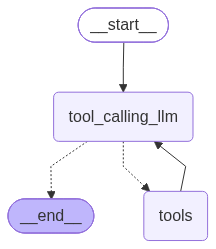

In [ ]:
## StateGraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",'tool_calling_llm')
# builder.add_edge('tool_calling_llm', END)

## compile the graph
graph=builder.compile()

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [59]:
response=graph.invoke({'messages': "Get me latest new on Laya Models and also multiply 2 by 10"})

In [60]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

Get me latest new on Laya Models and also multiply 2 by 10
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_9f83df86-a110-4e52-9060-84f471f13d6a)
 Call ID: fc_9f83df86-a110-4e52-9060-84f471f13d6a
  Args:
    query: Laya Models latest news
    search_depth: fast
    time_range: day
================================= Tool Message =================================
Name: tavily_search

{"query": "Laya Models latest news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://artificialintelligenceherald.com/ai-news-today", "title": "AI News Today — October 01, 2026 | Latest AI Updates | AI Herald", "content": "Publishing daily\n\n### Top AI Models in 2026\n\nClaude Fable 5 Anthropic   Claude Opus 4.8 Anthropic   Gemini Robotics Google DeepMind   Gemini Omni Google DeepMind   Grok 4.1 xAI   DeepSeek-Coder V2 DeepSe

### Adding Memory in Agentic Graph

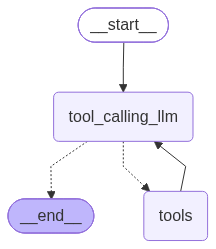

In [61]:
## StateGraph
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()

## Node definition
def tool_calling_llm(state:State):
    return {"messages":[llm_with_tool.invoke(state["messages"])]}

## Graph
builder=StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## Add Edges
builder.add_edge(START, "tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is a not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",'tool_calling_llm')
# builder.add_edge('tool_calling_llm', END)

## compile the graph
graph=builder.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))

In [62]:
config={'configurable': {"thread_id": '1'}}

In [63]:
res=graph.invoke({'messages': 'Hi my name is Suyash.'}, config=config)
res

{'messages': [HumanMessage(content='Hi my name is Suyash.', additional_kwargs={}, response_metadata={}, id='ce576f5f-ffdd-472d-bea5-dfa61580776f'),
  AIMessage(content='Hello Suyash! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user just says "Hi my name is Suyash." Probably they want a greeting. We should respond friendly. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 350, 'total_tokens': 407, 'completion_time': 0.120701151, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.022163717, 'prompt_tokens_details': None, 'queue_time': 0.343846376, 'total_time': 0.142864868}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6fb4303df4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fbbd-5acd-7de1-a417-57e8186b7948-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens':

In [66]:
res['messages'][-1].content


'Hello Suyash! Nice to meet you. How can I assist you today?'

In [67]:
res1=graph.invoke({'messages': 'what is my name?'}, config=config)
res1

{'messages': [HumanMessage(content='Hi my name is Suyash.', additional_kwargs={}, response_metadata={}, id='ce576f5f-ffdd-472d-bea5-dfa61580776f'),
  AIMessage(content='Hello Suyash! Nice to meet you. How can I assist you today?', additional_kwargs={'reasoning_content': 'The user just says "Hi my name is Suyash." Probably they want a greeting. We should respond friendly. No need to use tools.'}, response_metadata={'token_usage': {'completion_tokens': 57, 'prompt_tokens': 350, 'total_tokens': 407, 'completion_time': 0.120701151, 'completion_tokens_details': {'reasoning_tokens': 31}, 'prompt_time': 0.022163717, 'prompt_tokens_details': None, 'queue_time': 0.343846376, 'total_time': 0.142864868}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_6fb4303df4', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fbbd-5acd-7de1-a417-57e8186b7948-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens':

In [68]:
res1['messages'][-1].content

'Your name is Suyash.'

## Streaming

In [69]:
from langgraph.checkpoint.memory import MemorySaver

memory=MemorySaver()


In [70]:
def superbot(state:State):
    return {"messages":[llm.invoke(state["messages"])]}

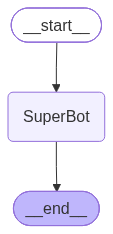

In [72]:
graph=StateGraph(State)

graph.add_node("SuperBot", superbot)

graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder=graph.compile(checkpointer=memory)

from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [73]:
config={"configurable": {'thread_id': "11"}}

In [79]:
response=graph_builder.invoke({"messages": "Hi there tell me some thing about Dots from open ai."}, config=config)

In [82]:
for m in response["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi there tell me some thing about jeffery epstine.
================================== Ai Message ==================================

Jeffrey Epstein (January 20 1953 – August 10 2019) was an American financier and convicted sex offender whose activities attracted intense public and legal scrutiny.

**Career and wealth**  
- Epstein began his career in finance at the investment bank Bear Stearns, later founding his own financial consulting firm, J. Epstein & Co., which claimed to manage assets for a small number of ultra‑high‑net‑worth clients.  
- He cultivated relationships with a number of prominent individuals in business, politics, academia, and entertainment, though the precise sources of his wealth have never been fully disclosed.

**Criminal allegations and convictions**  
- In 2005, the Palm Beach, Florida, police began investigating Epstein after a teenager reported that he had been paid for sexu

### Streaming
Methods: .stream() and astream()

These methods are sync and async methods for streaming back results.
Additional parameters in streaming modes for graph state

- **values** : This streams the full state of the graph after each node is called.
- **updates** : This streams updates to the state of the graph after each node is called.

In [83]:
# Create a thread
config = {"configurable": {"thread_id": "3"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Suyash And I watch anime"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content='Hey Suyash! 👋 Great to meet a fellow anime fan. What series are you currently watching, or do you have any all‑time favorites? 🎬✨', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is Suyash And I watch anime". Probably we should greet them, ask about favorite anime, etc. No policy issues. We\'ll respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 83, 'total_tokens': 171, 'completion_time': 0.187009345, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.004798708, 'prompt_tokens_details': None, 'queue_time': 0.317219166, 'total_time': 0.191808053}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fc0b-e095-7fe0-a1e1-28095a142e15-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_toke

In [84]:
for chunk in graph_builder.stream({'messages':"Hi,My name is Suyash And I watch anime"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Suyash And I watch anime', additional_kwargs={}, response_metadata={}, id='2b9d18ee-b05b-4c5b-b7ee-306a62c26ab9'), AIMessage(content='Hey Suyash! 👋 Great to meet a fellow anime fan. What series are you currently watching, or do you have any all‑time favorites? 🎬✨', additional_kwargs={'reasoning_content': 'We need to respond. The user says "Hi, My name is Suyash And I watch anime". Probably we should greet them, ask about favorite anime, etc. No policy issues. We\'ll respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 88, 'prompt_tokens': 83, 'total_tokens': 171, 'completion_time': 0.187009345, 'completion_tokens_details': {'reasoning_tokens': 44}, 'prompt_time': 0.004798708, 'prompt_tokens_details': None, 'queue_time': 0.317219166, 'total_time': 0.191808053}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_5082008e34', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_

In [85]:
# Create a thread
config = {"configurable": {"thread_id": "5"}}

for chunk in graph_builder.stream({'messages':"Hi,My name is Suyash And I watch anime"},config,stream_mode="updates"):
    print(chunk)

{'SuperBot': {'messages': [AIMessage(content="Hey Suyash! Nice to meet you. 😊  \nWhat kind of anime are you into? Any favorite series or genres you’d recommend? I'm always up for a good anime chat!", additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Suyash And I watch anime". Likely wants a response. We can greet, ask about favorite anime, etc. There\'s no disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 83, 'total_tokens': 175, 'completion_time': 0.196575481, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.025093134, 'prompt_tokens_details': None, 'queue_time': 0.317053329, 'total_time': 0.221668615}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_854fa9be4c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a0fc0d-ed7f-7e22-85f9-9e096c5d9bb3-0', tool_calls=[], invalid_tool_calls=[], usage_m

In [86]:
for chunk in graph_builder.stream({'messages':"i also read mangas"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='Hi,My name is Suyash And I watch anime', additional_kwargs={}, response_metadata={}, id='408e17ae-4903-4a87-8f6a-14693b2e88ac'), AIMessage(content="Hey Suyash! Nice to meet you. 😊  \nWhat kind of anime are you into? Any favorite series or genres you’d recommend? I'm always up for a good anime chat!", additional_kwargs={'reasoning_content': 'The user says "Hi, My name is Suyash And I watch anime". Likely wants a response. We can greet, ask about favorite anime, etc. There\'s no disallowed content. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 92, 'prompt_tokens': 83, 'total_tokens': 175, 'completion_time': 0.196575481, 'completion_tokens_details': {'reasoning_tokens': 45}, 'prompt_time': 0.025093134, 'prompt_tokens_details': None, 'queue_time': 0.317053329, 'total_time': 0.221668615}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_854fa9be4c', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logp

In [91]:
# Create a thread
config = {"configurable": {"thread_id": "67"}}

async for event in graph_builder.astream_events({"messages":["Hi,My name is Suyash And I watch anime"]},config,version="v2"):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': ['Hi,My name is Suyash And I watch anime']}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a0fc13-4cf3-7dd3-93ee-81a43eaa2d13', 'metadata': {'thread_id': '67', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='Hi,My name is Suyash And I watch anime', additional_kwargs={}, response_metadata={}, id='886416be-4b3d-49aa-9251-32cdfa61a373')]}}, 'name': 'SuperBot', 'tags': ['graph:step:1'], 'run_id': '01a0fc13-4cf7-7611-8d2e-f5bc89583300', 'metadata': {'thread_id': '67', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'SuperBot', 'langgraph_triggers': ('branch:to:SuperBot',), 'langgraph_path': ('__pregel_pull', 'SuperBot'), 'langgraph_checkpoint_ns': 'SuperBot:05fc6649-43a1-edac-35e1-d559420f5d71'}, 'parent_ids': ['01a0fc13-4cf3-7dd3-93ee-81a43eaa2d13']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessag